In [1]:
#import libs
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [2]:
#loading in our data
adata = sc.read_10x_h5(r"C:\Users\mniu\Documents\neuroblastoma-multiome\data\raw\GSM8159271_Be2c_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
print(adata)

C:\envs\nb\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 18473 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'


C:\envs\nb\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
#check my data
print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")
print(adata.var.head())
print(adata.obs.head())

Cells: 18473, Genes: 36601
                    gene_ids    feature_types  genome            interval
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38    chr1:29553-30267
FAM138A      ENSG00000237613  Gene Expression  GRCh38    chr1:36080-36081
OR4F5        ENSG00000186092  Gene Expression  GRCh38    chr1:65418-69055
AL627309.1   ENSG00000238009  Gene Expression  GRCh38  chr1:120931-133723
AL627309.3   ENSG00000239945  Gene Expression  GRCh38    chr1:91104-91105
Empty DataFrame
Columns: []
Index: [AAACAGCCAAACTAAG-1, AAACAGCCAAGCGAGC-1, AAACAGCCAATTGAGA-1, AAACAGCCACAAAGCG-1, AAACAGCCACCCACCT-1]


In [4]:
#identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [5]:
#check how many MT genes found
print(f"Mitochondrial genes found; {adata.var['mt'].sum()}")
print(adata.var[adata.var['mt']].index.tolist())

Mitochondrial genes found; 13
['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']


In [6]:
#calculate qc metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top = None, log1p = False, inplace = True)

In [7]:
#take a look at data
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

       n_genes_by_counts   total_counts  pct_counts_mt
count       18473.000000   18473.000000   18473.000000
mean         3744.386185    9295.402344       5.311253
std          1494.276177    7490.047852       5.912199
min            77.000000      83.000000       0.090646
25%          2954.000000    5346.000000       1.319971
50%          3668.000000    7694.000000       3.240895
75%          4539.000000   11292.000000       7.098121
max         15121.000000  338017.000000      68.494789


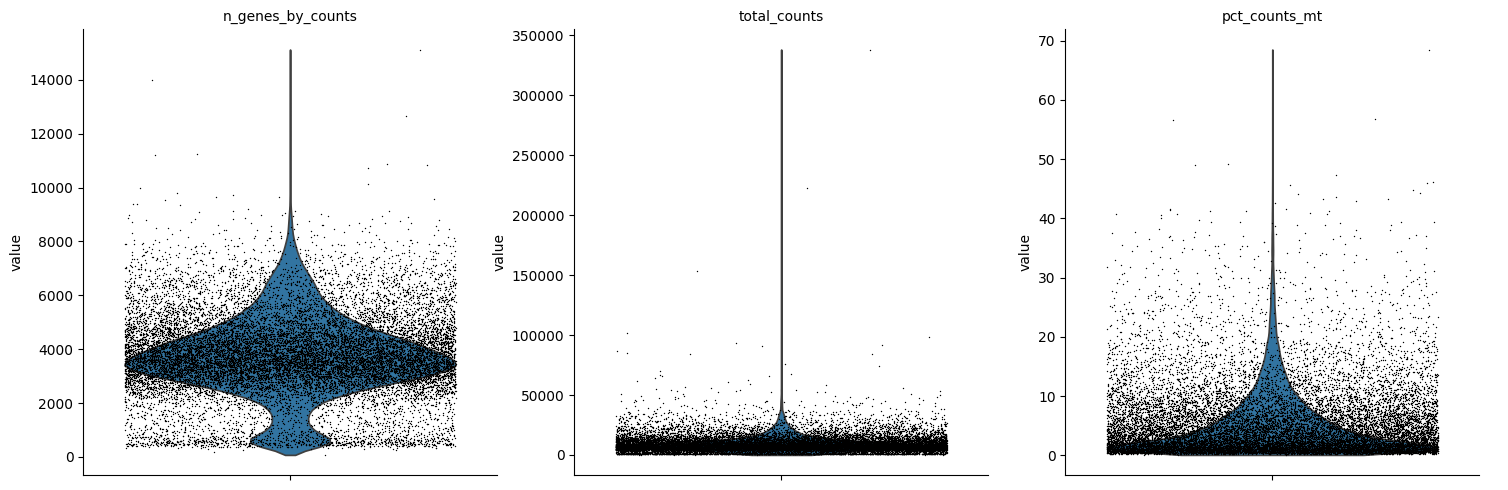

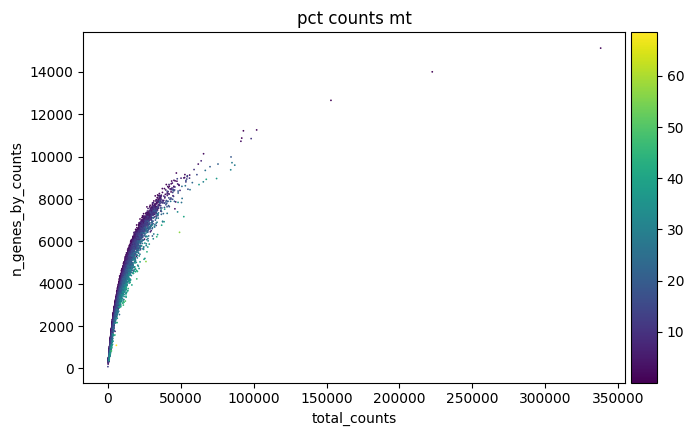

In [8]:
#look at violin plots
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter = 0.4, multi_panel = True)
#scatter plot
sc.pl.scatter(adata, x = 'total_counts', y = 'n_genes_by_counts', color = 'pct_counts_mt')

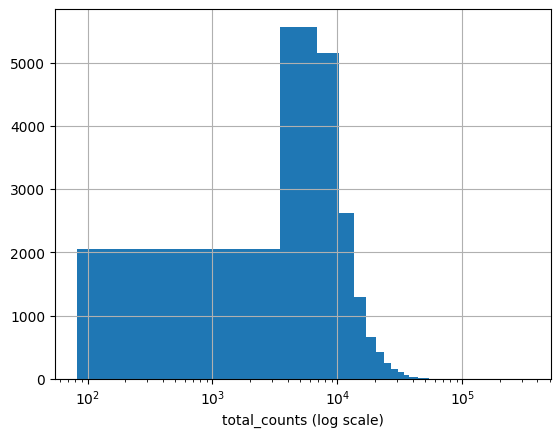

In [9]:
#another plot for visualization
import numpy as np
adata.obs['total_counts'].hist(bins=100)
plt.xscale('log')
plt.xlabel('total_counts (log scale)')
plt.show()

## Day 1 observations - Be2c RNA QC
- Main population: ~3000-5000 genes/cell, <50000 total counts, <15% MT
- Secondary low-count cluster (~500-1500 genes) - possible low-quality cells
- Outliers at >200000 total counts - likely doublets
- High MT% concentrated in low total_counts cells, as expected

**Planned thresholds for tomorrow**: min_genes=500-1000, max_counts~100000, pct_mt<15-20%

In [10]:
print(f"Before filtering: {adata.shape}")

Before filtering: (18473, 36601)


In [11]:
#Basic filtering
sc.pp.filter_cells(adata, min_genes = 1000)
sc.pp.filter_genes(adata, min_cells = 3)
print(f"After min_genes/min_cells: {adata.shape}")

After min_genes/min_cells: (17376, 28110)


Predicted doublets: 0


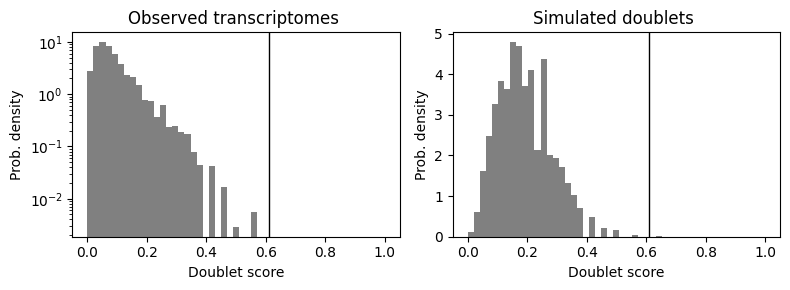

In [12]:
#scrublet doublet detection (replaces total_counts heuristic
sc.pp.scrublet(adata)
print(f"Predicted doublets: {adata.obs['predicted_doublet'].sum()}")
sc.pl.scrublet_score_distribution(adata)

In [13]:
#Filter based on QC metrics
adata = adata[adata.obs.total_counts < 100000].copy()
adata = adata[adata.obs.pct_counts_mt < 20].copy()

print(f"After filtering: {adata.shape}")

After filtering: (16818, 28110)


In [14]:
print(f"Cells removed: {18473 - adata.n_obs} ({(18473 - adata.n_obs)/18473*100:.1f}%)")

Cells removed: 1655 (9.0%)


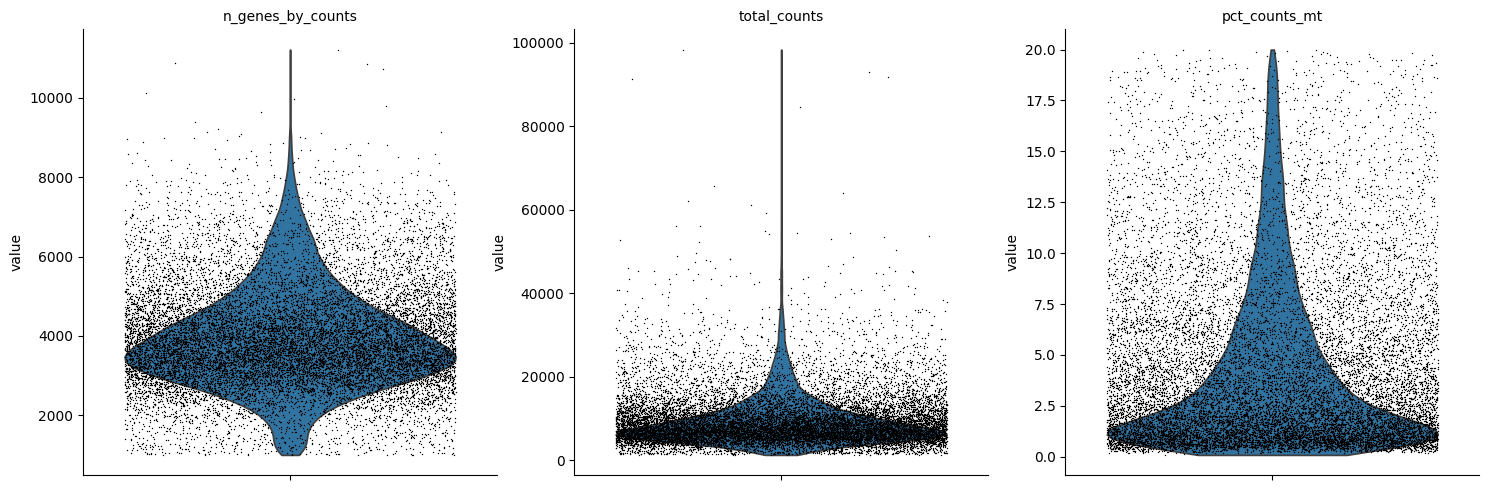

In [15]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter = 0.4, multi_panel = True)

In [16]:
#save filtered data
adata.write_h5ad(r"C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\Be2c_rna_filtered.h5ad")

## Day 2 - Filtering Decisions
Applied thresholds: min_genes = 1000, max_counts = 100000, pct_mt < 20%
Result: 18473 cells -> 16818 cells (9% removed)

Reasoning: Day 1 plots showed a secondary low-count population (~500-1500 genes) likely representing low-quality/empty droplets, and outliers up to 350000 total counts likely representing doublets. 

Attempted Scrublet doublet detection as a better alternative to total_counts, but Scrublet's automatic threshold found no clear bimodal separation in observed vs. simulated doublet scores, predicting 0 doublets: likely ebcaise Be2c is a homogenous cell line, where doublets of two identical cells are transcroptionally similar to singlets (a known limiation of Scrublet on homogenous samples).  Kept the total_counts method as the primary doublet-removal approach: doublet_score retained in .obs for reference.

In [17]:
#normalize
sc.pp.normalize_total(adata, target_sum = 1e4)
print(adata.X.sum(axis = 1)[:5])

[[ 9999.998]
 [10000.001]
 [ 9999.999]
 [10000.   ]
 [ 9999.999]]


In [18]:
#log transform
sc.pp.log1p(adata)

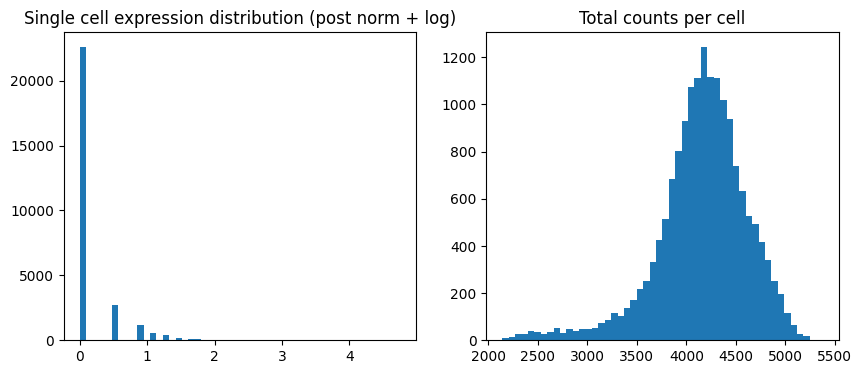

In [20]:
#visualization, compare a few cells' total expression distribution
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
axes[0].hist(adata.X[0, :].toarray().flatten() if hasattr(adata.X, 'toarray') else adata.X[0, :], bins = 50)
axes[0].set_title("Single cell expression distribution (post norm + log)")
axes[1].hist(np.asarray(adata.X.sum(axis = 1)).flatten(), bins = 50)
axes[1].set_title("Total counts per cell")
plt.show()

In [21]:
adata.raw = adata

In [27]:
adata.write_h5ad(r"C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\Be2c_rna_normalized.h5ad")

## Day 3 - Normalization + Log Transform
Applied sc.pp.normalize_total(target_sum = 1e4) and sc.pp.log1p().
Reasoning: Raw counts reflect both biological expression differences and technical sequencing depth differences between cells. Normalizing to a common total count removes the depth artifact, making expression values comparable across cells. Log transformation compresses the right-skewed count distribution, stabilizing variance for downstream PCA/clustering, which assume approximately normally-distributed data.
Saved adata.raw as a checkpoint before HVG selection on Day 4, preserving access to all genes for later reference.